<a href="https://colab.research.google.com/github/Chen-M-22/GridCast/blob/main/02_baselines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
historical_demand_df = pd.read_csv('ercot_hourly_demand_2020_2025_clean.csv', parse_dates=['timestamp'])

In [5]:
historical_demand_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  52608 non-null  datetime64[ns]
 1   demand     52608 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 822.1 KB


In [6]:
historical_demand_df.isna().sum()

,0
timestamp,0
demand,0


In [7]:
historical_demand_df['timestamp'].duplicated().sum()

np.int64(0)

In [8]:
historical_demand_df['timestamp'].diff().value_counts()

,count
timestamp,
0 days 01:00:00,52607


# Time Series Forecasting Set Up

The ERCOT demand data form a continuous hourly time series. For forecasting, the series is transformed into supervised learning samples using a sliding window.

In [9]:
# constructing sequence X_t and Target Y_t
# X_t = [demand_{t-input_length}, ..... demand_[t-1]]
# Y_t = [demand_{t}, ..... demand_{t+horizon-1}]

input_length = 168 # 24 hrs * 7 days
horizon = 24

x = []
y = []
target_start_times = []
target_end_times = []

for i in range (input_length, len(historical_demand_df) - horizon + 1):
  x.append(historical_demand_df['demand'].iloc[i-input_length: i].values)
  y.append(historical_demand_df['demand'].iloc[i: i+horizon].values)

  target_start_times.append(historical_demand_df['timestamp'].iloc[i])
  target_end_times.append(historical_demand_df['timestamp'].iloc[i+horizon-1])


In [10]:
# Train-Validation-Test Split

target_start_times = pd.Series(target_start_times)
target_end_times = pd.Series(target_end_times)

train_mask = target_end_times < pd.Timestamp('2024-01-01')
validation_mask = (target_start_times >= pd.Timestamp('2024-01-01')) & (target_end_times < pd.Timestamp('2025-01-01'))
test_mask = (target_start_times >= pd.Timestamp('2025-01-01'))

In [11]:
print('Total Windows:', len(x))
print('Total Train:', train_mask.sum())
print('Total Validation:', validation_mask.sum())
print('Total Test:', test_mask.sum())
print('Excluded:', len(x) - train_mask.sum() - validation_mask.sum() - test_mask.sum())

Total Windows: 52417
Total Train: 34873
Total Validation: 8761
Total Test: 8737
Excluded: 46


In [12]:
x = np.array(x)
y = np.array(y)

print('X shape:', x.shape)
print('Y shape:', y.shape)

X shape: (52417, 168)
Y shape: (52417, 24)


In [13]:
x_train = x[train_mask]
x_val = x[validation_mask]
x_test = x[test_mask]

y_train = y[train_mask]
y_val = y[validation_mask]
y_test = y[test_mask]

In [14]:
print('Train Dataset:', x_train.shape, y_train.shape)
print('Validation Dataset:', x_val.shape, y_val.shape)
print('Test Dataset:', x_test.shape, y_test.shape)

Train Dataset: (34873, 168) (34873, 24)
Validation Dataset: (8761, 168) (8761, 24)
Test Dataset: (8737, 168) (8737, 24)


# Baseline Models

In [15]:
# Daily seasonal baseline: predict the next 24 hours using the previous 24 hours.

y_val_pred_daily = x_val[:, -24: ]

In [16]:
val_daily_mae = np.mean(np.abs(y_val_pred_daily - y_val))
val_daily_rmse = np.sqrt(np.mean(np.square(y_val_pred_daily - y_val)))

In [17]:
print('Validation MAE:', val_daily_mae)
print('Validation RMSE:', val_daily_rmse)

Validation MAE: 2353.573117604535
Validation RMSE: 3402.534706938884


In [18]:
# Weekly seasonal baseline: predict the next 24 hours using the corresponding 24-hour period in the previous week

y_val_pred_weekly = x_val[:, :24]

In [19]:
val_weekly_mae = np.mean(np.abs(y_val_pred_weekly - y_val))
val_weekly_rmse = np.sqrt(np.mean(np.square(y_val_pred_weekly - y_val)))

In [20]:
print('Validation MAE:', val_weekly_mae)
print('Validation RMSE:', val_weekly_rmse)

Validation MAE: 4488.898694022752
Validation RMSE: 6279.168714886132


In [21]:
mean_val_demand = y_val.mean()

normalized_val_daily_mae = (val_daily_mae / mean_val_demand) * 100
normalized_val_weekly_mae = (val_weekly_mae / mean_val_demand) * 100

In [22]:
print('Normalized Validation MAE of Daily Seasonal Baseline: ', normalized_val_daily_mae)
print('Normalized Validation MAE of Weekly Seasonal Baseline: ', normalized_val_weekly_mae)

Normalized Validation MAE of Daily Seasonal Baseline:  4.455957910731479
Normalized Validation MAE of Weekly Seasonal Baseline:  8.498713507766974


In [23]:
daily_mae_by_horizon = np.mean(np.abs(y_val_pred_daily - y_val), axis=0)
daily_mae_by_horizon

array([2354.18559525, 2354.45542746, 2354.71806871, 2354.85572423,
       2354.86702431, 2354.73404862, 2354.47928319, 2354.18513868,
       2353.95171784, 2353.80915421, 2353.666933  , 2353.47837005,
       2353.31754366, 2353.20614085, 2353.0916562 , 2352.89978313,
       2352.74420728, 2352.72400411, 2352.61488415, 2352.51512384,
       2352.51603698, 2352.6947837 , 2352.92169844, 2353.1224746 ])

In [24]:
weekly_mae_by_horizon = np.mean(np.abs(y_val_pred_weekly - y_val), axis=0)
weekly_mae_by_horizon

array([4489.18433969, 4489.33740441, 4489.30647186, 4489.26275539,
       4489.21960963, 4489.19723776, 4489.16002739, 4489.10021687,
       4488.97911197, 4488.82878667, 4488.68519575, 4488.59308298,
       4488.55667161, 4488.61271544, 4488.73187992, 4488.84853327,
       4488.84214131, 4488.76794886, 4488.75756192, 4488.7512841 ,
       4488.77023171, 4488.7915763 , 4488.72446068, 4488.55941103])

In [25]:
# Prediction Demonstration

sample_index = 6513

actual = y_val[sample_index]
pred_daily = y_val_pred_daily[sample_index]
pred_weekly = y_val_pred_weekly[sample_index]

print('Actual Demands:', actual)
print('Daily Seasonal Baseline Prediction:', pred_daily)
print('Weekly Seasonal Baseline Prediction:', pred_weekly)

Actual Demands: [41658. 41241. 41014. 41299. 42023. 44915. 48779. 51364. 54312. 57106.
 60157. 62732. 65293. 66881. 66784. 64627. 61209. 58477. 55672. 52517.
 49454. 46474. 44463. 42590.]
Daily Seasonal Baseline Prediction: [42048. 41683. 42589. 44386. 45351. 47949. 50911. 52543. 54805. 57546.
 60602. 63313. 65032. 66352. 66140. 63859. 60609. 57917. 55125. 52203.
 49616. 46778. 44601. 42780.]
Weekly Seasonal Baseline Prediction: [51051. 50003. 49659. 49900. 50289. 52846. 57857. 62631. 66446. 69422.
 72118. 74521. 75813. 76518. 75942. 73573. 70317. 67768. 65032. 61844.
 58721. 55621. 53507. 51289.]


In [30]:
val_target_start_times = target_start_times[validation_mask].reset_index(drop=True)
val_target_end_times = target_end_times[validation_mask].reset_index(drop=True)

print('Forecast Period:')
print(val_target_start_times.iloc[sample_index], 'to', val_target_end_times.iloc[sample_index])

Forecast Period:
2024-09-28 09:00:00 to 2024-09-29 08:00:00


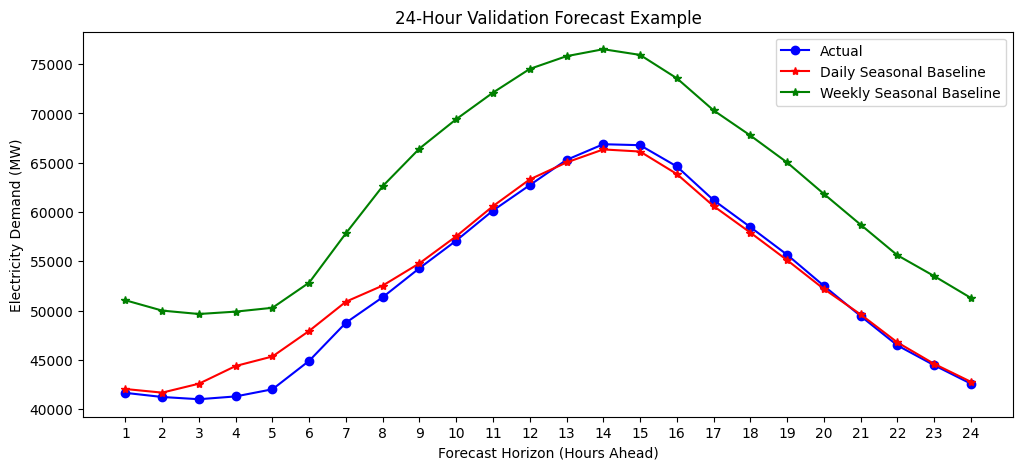

In [39]:
hours_ahead = np.arange(1, 25)

plt.figure(figsize=(12, 5))

plt.plot(hours_ahead, actual, color='blue', marker='o', label='Actual')
plt.plot(hours_ahead, pred_daily, color='red', marker='*', label='Daily Seasonal Baseline')
plt.plot(hours_ahead, pred_weekly, color='green', marker='*', label='Weekly Seasonal Baseline')

plt.xlabel('Forecast Horizon (Hours Ahead)')
plt.ylabel('Electricity Demand (MW)')
plt.title('24-Hour Validation Forecast Example')
plt.xticks(range(1, 25))
plt.legend()

plt.show()

In [42]:
# MAE and RMSE Summary

baseline_model_results = pd.DataFrame(
    {
        'Model': ['Daily Seasonal Baseline', 'Weekly Seasonal Baseline'],
        'MAE (MW)' : [val_daily_mae, val_weekly_mae],
        'RMSE (MW)' : [val_daily_rmse, val_weekly_rmse],
        'Normalized MAE (%)': [normalized_val_daily_mae, normalized_val_weekly_mae]
    }
)

baseline_model_results.round(2)

,Model,MAE (MW),RMSE (MW),Normalized MAE (%)
0,Daily Seasonal Baseline,2353.57,3402.53,4.46
1,Weekly Seasonal Baseline,4488.90,6279.17,8.50


The daily seasonal baseline substantially outperforms the weekly seasonal baseline on the 2024 validation set. Its MAE is approximately 2353.57 MW, corresponding to about 4.46% of the mean validation demand, compared with about 4488.90 MW and 8.50% for the weekly seasonal baseline. The suggests that the immediate proceeding day provides a stronger short-term forecasting signal than the corresponding period one week prior.